In [ ]:
%load_ext cudf.pandas

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/kaggle/input/datasets/organizations/crowdflower/twitter-airline-sentiment/Tweets.csv")

In [ ]:
df.head()

## Phase 1 : EDA

### Checking for null values

In [ ]:
print(f"TOTAL NUMS OF SAMPLES : {df.shape}\n\n")
print(f"TOTAL NUMS OF NULL VALUES : \n\n{df.isna().sum()}\n\n")
print(f"TOTAL NUMS OF NULL VALUES : \n\n{df.isna().mean()*100}\n")

Since feature "airline_sentiment_gold", "negativereason_gold", and "tweet_coord" are having more than 90 % of missing values, so we will be removing them.

In [ ]:
df_1 = df.drop(columns=['tweet_coord','negativereason_gold','airline_sentiment_gold'])

In [ ]:
# checking for remaining null values in df_1 
print(f"TOTAL FEATURES : {df_1.shape[1]}\n\n")
print(f"TOTAL NUMS OF NULL VALUES : \n\n{df_1.isna().sum()}\n\n")
print(f"TOTAL NUMS OF NULL VALUES : \n\n{df_1.isna().mean()*100}\n")

In [ ]:
df_1.sample(3)

In [ ]:
df_1.info()

In [ ]:
df_1.columns.tolist()

### Changing the column names

In [ ]:
dict = {
    'tweet_id':'id',
     'airline_sentiment':'sentiment',
     'airline_sentiment_confidence':'sentiment_confidence',
     'negativereason':'reason',
     'negativereason_confidence':'reason_confidence',
     'airline':'airlines',
     'name':'name',
     'retweet_count':'retweets',
     'text':'feedback',
     'tweet_created':'date_time',
     'tweet_location':'location',
     'user_timezone':'timezone'
    }


df_1 = df_1.rename(columns=dict)

In [ ]:
df_1.columns.tolist()

In [ ]:
df_1 = df_1[['id','name','date_time', 'location', 'timezone','airlines','feedback','reason','reason_confidence','retweets','sentiment','sentiment_confidence']]
df_1.sample(5)

In [ ]:
df_1.isna().sum()

In [ ]:
df_1.info()

In [ ]:
df_1.dtypes.unique()

In [ ]:
df_1.dtypes[df_1.dtypes == 'object'].reset_index()

In [ ]:
df_1.dtypes[df_1.dtypes == 'int'].reset_index()

In [ ]:
df_1.dtypes[df_1.dtypes == 'float'].reset_index()

In [ ]:
pd.DataFrame({'Missing Values': df_1.isna().sum(), 'Data Type': df_1.dtypes})

In [ ]:
df_1.nunique()

In [ ]:
import datetime as dt

In [ ]:
# converting date_time into datetime format
df_1['date_time'] = pd.to_datetime(df_1['date_time'])
df_1.dtypes

In [ ]:
df_1['date'] = df_1['date_time'].dt.date
df_1['time'] = df_1['date_time'].dt.time

In [ ]:
df_1 = df_1[['id','name','date','time', 'timezone','airlines','feedback','reason','reason_confidence','retweets','sentiment','sentiment_confidence']]
df_1.sample(5)

### Fixing the TimeZones

In [ ]:
df_1['timezone'].unique().tolist()

In [ ]:
df_1['timezone'] = df_1['timezone'].str.replace(" (US & Canada)", "")
df_1['timezone'] = df_1['timezone'].str.replace(" ", "_")

In [ ]:
# other way to do the same as above
timezone_fixes = {
    # Fixing the Eastern Time duplicates
    'America/New_York': 'Eastern_Time',
    'America/Detroit': 'Eastern_Time',
    'EST': 'Eastern_Time',
    'Indiana_(East)': 'Eastern_Time',
    
    # Fixing the Central Time duplicates
    'America/Chicago': 'Central_Time',
    
    # Fixing the Mountain Time duplicates
    'America/Boise': 'Mountain_Time',
    
    # Fixing the Pacific Time duplicates
    'America/Los_Angeles': 'Pacific_Time'
}

df_1['timezone'] = df_1['timezone'].replace(timezone_fixes)

In [ ]:
df_1['timezone'].unique()

### Fixing the Airlines

In [ ]:
df_1['airlines'].unique()

In [ ]:
df_1['airlines'] = df_1['airlines'].str.replace(" ", "_")

In [ ]:
df_1['airlines'].unique()

In [ ]:
pd.DataFrame({'MISSING VALUES':df_1.isna().sum(), 'DTYPES':df_1.dtypes})

In [ ]:
df_1.sample(6)

In [ ]:
df_1['date'] = pd.to_datetime(df_1['date'])
df_1['hour'] = df_1['time'].apply(lambda x : x.hour)


In [ ]:
df_1['hour'].unique()

In [ ]:
df_1 = df_1[['id','name','date','hour', 'timezone','airlines','feedback','reason','reason_confidence','retweets','sentiment']]


In [ ]:
df_1.sample(6)

In [ ]:
pd.DataFrame({'MISSING VALUES':df_1.isna().sum(), 'UNIQUE VALUES':df_1.nunique(), 'DTYPES':df_1.dtypes})

### Fixing Feedback feature

In [ ]:
df_1.loc[:, ['airlines','feedback']].sample(20)

# as we can there is tag like "@....", so we have to remove every word starting with @

In [ ]:
# repalcing tags
condition = r'@\w+ '
df_1['feedback'] = df_1['feedback'].str.replace(condition, "", regex=True)


In [ ]:
df_1['feedback']

In [ ]:
pd.DataFrame({'MISSING VALUES':df_1.isna().sum(), 'UNIQUE VALUES':df_1.nunique(), 'DTYPES':df_1.dtypes})

In [ ]:
df_1.sample(6)

In [ ]:
df_1['reason'].unique()

### Using KNN for handling missing values
- But before using KNN we need to apply OHE on timezone and reason

In [ ]:
pd.DataFrame({'MISSING VALUES':df_1.isna().sum(), 'UNIQUE VALUES':df_1.nunique(), 'DTYPES':df_1.dtypes})

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

In [ ]:
# printing only the nan column names
nan_cols = df_1.columns[df_1.isna().any()].tolist()
nan_cols

In [ ]:
# grabbing all categorical cols
cat_cols = ['timezone', 'reason', 'airlines', 'sentiment']

# using OHE on all categorical cols
df_ohe_transformed = pd.get_dummies(df_1[cat_cols])
# here what happend is all NaN cells in timezone and reason have also been converted into columns due to OHE

In [ ]:
condition = df_1[['timezone', 'reason']].isna()                                      # step - 1 : taking null values from timezone and reason

for col in ['timezone', 'reason']:
    temp_cols = [i for i in df_ohe_transformed.columns if i.startswith(col + '_')] 
    df_ohe_transformed.loc[condition[col], temp_cols] = np.nan                       # step - 2 : putting nan values at the empty cells

In [ ]:
# combining rest of the numerical features with the ohe transformed features for better accuracy
numeric_cols = df_1[['reason_confidence', 'retweets', 'hour']]
all_features = pd.concat([df_ohe_transformed, numeric_cols], axis=1)

# applying KNN
knn = KNNImputer(n_neighbors=10, weights='distance')

imputed_array = knn.fit_transform(all_features)

df_imputed = pd.DataFrame(imputed_array, columns=all_features.columns, index=all_features.index)

In [ ]:
imputed_array.sample(6)

In [ ]:
df_imputed.sample(6)

In [ ]:
print(df_imputed.shape)

df_imputed.isna().sum().sum()

In [ ]:
df_imputed.sample(10)

In [ ]:
reason_col = [c for c in df_imputed.columns if c.startswith('reason_') and c!= 'reason_confidence']
timezone_col = [c for c in df_imputed.columns if c.startswith('timezone_')]

In [ ]:
temp = df_imputed[['reason_confidence']].copy()

# to convert OHE encoded values back into the normal feature we use 'idxmax(axis=1)' 
temp['reason'] = df_imputed[reason_col].idxmax(axis=1).str.replace('reason_','')
temp['timezone'] = df_imputed[timezone_col].idxmax(axis=1).str.replace('timezone_','')

temp

In [ ]:
temp.isna().sum()

In [ ]:
temp['reason_confidence'].describe()

In [ ]:
# replacing the columns with nan values in df_1 with imputed values from temp
df_1[['reason_confidence', 'reason', 'timezone']] = temp[['reason_confidence', 'reason', 'timezone']]

In [ ]:
pd.DataFrame({
    'NULL VAUES':df_1.isna().sum(),
    'UNIQUE VALUES':df_1.nunique(),
    'DTYPES':df_1.dtypes
})

In [ ]:
df_1.select_dtypes(include='object')

In [ ]:
print(sorted(df_1['hour'].unique().tolist()))
df_1['hour'].nunique()

---
**WHILE DOING MODEL TRAINING DO THE BELOW, TO MAKE THE MODEL UNDERSTAND THE HOUR BETTER**

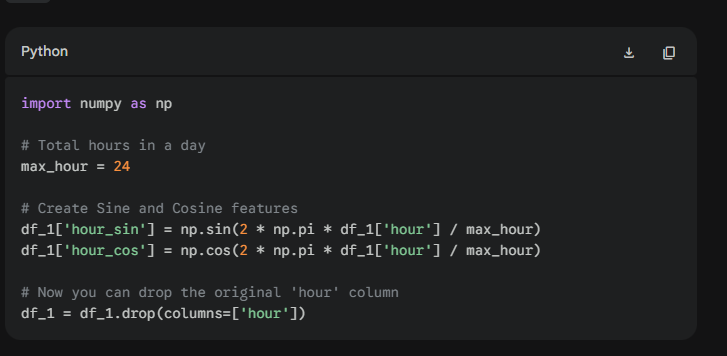

---

In [ ]:
df_1['day_name'] = df_1['date'].dt.day_name()
df_1 = df_1[['id', 'name', 'date', 'day_name', 'hour', 'timezone', 'airlines', 'feedback', 'reason', 'reason_confidence', 'retweets', 'sentiment']]


In [ ]:
df_1.sample(10)